In [37]:
import torch 
import torch.nn as nn
import torch.nn.functional as F

from tqdm import tqdm
import matplotlib.pyplot as plt

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

In [38]:
import torch
import torch.nn as nn
import torch.nn.functional as F

class WSConv2d(nn.Module):
    def __init__(self, in_channels, out_channels, kernel_size=3, stride=1, padding=1, gain=2):
        super().__init__()
        # Initialize the convolution layer
        self.conv = nn.Conv2d(in_channels, out_channels, kernel_size, stride, padding)
        
        # Calculate the He constant (scale factor)
        # Formula: sqrt(gain / fan_in)
        self.scale = (gain / (in_channels * (kernel_size ** 2))) ** 0.5
        
        # Pull the bias out so we can apply it AFTER the scaled convolution
        self.bias = nn.Parameter(torch.zeros(out_channels))
        
        # Initialize weights to N(0, 1). 
        # The scale factor will handle the variance.
        nn.init.normal_(self.conv.weight)
        self.conv.bias = None # Remove original bias to prevent double-biasing

    def forward(self, x):
        # Scale weights on the fly (Equalized Learning Rate)
        # This keeps gradients healthy and the optimizer stable.
        scaled_weight = self.conv.weight * self.scale
        
        # Use functional conv2d to apply the scaled weights
        out = F.conv2d(
            x, 
            scaled_weight, 
            bias=None, 
            stride=self.conv.stride, 
            padding=self.conv.padding
        )
        
        # Add the bias manually
        return out + self.bias.view(1, self.bias.shape[0], 1, 1)

In [39]:
class PixelNorm(nn.Module):
    def __init__(self,epsilon=1e-5):
        super().__init__()
        self.epsilon = epsilon

    def forward(self, x):
        return x / torch.sqrt(torch.mean(x ** 2, dim=1, keepdim=True) + self.epsilon)

In [40]:
class ConvBlock(nn.Module):
    def __init__(self, 
                 in_channels, 
                 out_channels, 
                 use_pixel_norm=True):
        super().__init__()
        self.conv1 = WSConv2d(in_channels, out_channels)
        self.conv2 = WSConv2d(out_channels, out_channels)
        self.leaky_relu = nn.LeakyReLU(0.2,inplace=True)
        self.pixel_norm = PixelNorm()
        self.use_pixel_norm = use_pixel_norm
    
    def forward(self, x):
        x = self.conv1(x)
        x = self.leaky_relu(x)
        if self.use_pixel_norm:
            x = self.pixel_norm(x)

        x = self.conv2(x)
        x = self.leaky_relu(x)
        if self.use_pixel_norm:
            x = self.pixel_norm(x)
        return x
       


In [41]:
class Generator(nn.Module):
    def __init__(self,
                 z_dim,
                 channels,
                 img_channels):
        super().__init__()
        self.z_dim = z_dim
        self.channels = channels.copy()
        self.img_channels = img_channels

        self.initial_block = nn.Sequential(
            PixelNorm(),
            nn.ConvTranspose2d(z_dim, self.channels[0], kernel_size=4, stride=1, padding=0, bias=False),
            nn.LeakyReLU(0.2,inplace=True),
            WSConv2d(self.channels[0], self.channels[0], kernel_size=1, stride=1, padding=0),
            nn.LeakyReLU(0.2,inplace=True),
            PixelNorm(),
        )

        self.initial_rgb = WSConv2d(self.channels[0], img_channels, kernel_size=1, stride=1, padding=0)

        self.prog_blocks, self.rgb_layers = nn.ModuleList(), nn.ModuleList([self.initial_rgb])

        for i in range(len(self.channels) - 1):
            self.prog_blocks.append(ConvBlock(self.channels[i],self.channels[i+1]))
            self.rgb_layers.append(WSConv2d(self.channels[i+1], img_channels, kernel_size=1, stride=1, padding=0))

        
    def fade_in(self, alpha,upscaled,generated):
        return (alpha*generated + (1-alpha)*upscaled)
    
    def forward(self, x,alpha,steps):
        out = self.initial_block(x)
        if steps ==0:
            out = self.initial_rgb(out)
        else:
            for step in range(steps):
                upscaled = F.interpolate(out, scale_factor=2, mode='nearest')
                out = self.prog_blocks[step](upscaled)

            final_upscaled = self.rgb_layers[steps-1](upscaled)
            out = self.rgb_layers[steps](out)

            
            if alpha <1.0:
                out = self.fade_in(alpha,final_upscaled,out)
        
        return torch.tanh(out)

    


In [42]:
class Discriminator(nn.Module):
    def __init__(self,channels, img_channels=3):
        super().__init__()
        self.channels = channels.copy()
        self.img_channels = img_channels
        self.total_steps = len(self.channels)

        self.leacky = nn.LeakyReLU(0.2,inplace=True)
        self.avg_pool = nn.AvgPool2d(kernel_size=2,stride=2)

        self.prog_blocks, self.rgb_layers = nn.ModuleList(), nn.ModuleList()

        for i in range(len(self.channels)):
            self.rgb_layers.append(WSConv2d(self.img_channels,self.channels[i],kernel_size=1,stride=1,padding=0))

        for i in range(len(self.channels)-1):
            self.prog_blocks.append(ConvBlock(self.channels[i+1],self.channels[i],use_pixel_norm=False))

        # self.prog_blocks, self.rgb_layers = nn.ModuleList(), nn.ModuleList()
        # for i in range(len(self.channels),1,-1):
        #     self.prog_blocks.append(ConvBlock(self.channels[i],self.channels[i-1],use_pixel_norm=False))
        #     self.rgb_layers.append(WSConv2d(self.img_channels,self.channels[i-1],kernel_size=1,stride=1,padding=0))

        
        # self.initial_rgb = WSConv2d(self.img_channels,self.channels[-1],kernel_size=1,stride=1,padding=0)
        # self.rgb_layers.append(self.initial_rgb)
        # self.avg_pool = nn.AvgPool2d(kernel_size=2,stride=2)

        self.final_block = nn.Sequential(
            WSConv2d(self.channels[0]+1,self.channels[0],kernel_size=3,stride=1,padding=1),
            nn.LeakyReLU(0.2,inplace=True),
            WSConv2d(self.channels[0],self.channels[0],kernel_size=4,stride=1,padding=0),
            nn.LeakyReLU(0.2,inplace=True),
            WSConv2d(self.channels[0],1,kernel_size=1,stride=1,padding=0),
        )

    def fade_in(self,alpha,downscaled,out):
        return alpha *out + (1-alpha)*downscaled

    def minibatch_std(self, x):
        batch_statistics =torch.std(x,dim=0).mean().repeat(x.shape[0],1,x.shape[2],x.shape[3])
        return torch.cat([x,batch_statistics],dim=1)
    
    def forward(self, x,alpha,steps):
            
        out = self.rgb_layers[steps](x)

        if steps !=0:
            out = self.prog_blocks[steps-1](out)
            out = self.avg_pool(out)

            downsampled = self.avg_pool(x)
            downsampled = self.rgb_layers[steps-1](downsampled)

            out = self.fade_in(alpha,downsampled,out)

            for s in range(steps-2,-1,-1):
                out = self.prog_blocks[s](out)
                out = self.avg_pool(out)

        out = self.minibatch_std(out)
        out = self.final_block(out)
        return out.view(out.shape[0],-1)
    



In [43]:

def gradient_penalty(critic, real, fake, alpha, train_step, device="cpu"):
    BATCH_SIZE, C, H, W = real.shape
    beta = torch.rand((BATCH_SIZE, 1, 1, 1)).repeat(1, C, H, W).to(device)
    interpolated_images = real * beta + fake.detach() * (1 - beta)
    interpolated_images.requires_grad_(True)

    # Calculate critic scores
    mixed_scores = critic(interpolated_images, alpha, train_step)

    # Take the gradient of the scores with respect to the images
    gradient = torch.autograd.grad(
        inputs=interpolated_images,
        outputs=mixed_scores,
        grad_outputs=torch.ones_like(mixed_scores).to(mixed_scores.device),
        create_graph=True,
        retain_graph=True,
    )[0]
    gradient = gradient.view(gradient.shape[0], -1)
    gradient_norm = gradient.norm(2, dim=1)
    gradient_penalty = torch.mean((gradient_norm - 1) ** 2)
    return gradient_penalty


In [44]:

channels = [512,512,512,256,128,64,32]
# channels = [16] * len(channels)
sizes = [4 *(2**i) for i in range(len(channels)-2)]
z_dim  = 512
img_channels =3
batch_sizes = [64,64,32,16,8,4,4]
# assert len(batch_sizes) == len(sizes)

epochs = 20

disc_lr= 0.0002
gen_lr= 0.0002
LAMBDA_GP  =10
critic_mean_penalty = 0.001
alpha_start = 1e-5

In [45]:
from CityScapes.datasets.progan_dataset import ProGanCityscapesDataset
from torch.utils.data import DataLoader


datasets = [ProGanCityscapesDataset(size=s) for s in sizes]
dataloaders = [DataLoader(d, batch_size=b_size, shuffle=True) for d,b_size in zip(datasets,batch_sizes)]


gen = Generator(z_dim =z_dim,
                channels=channels,
                img_channels=img_channels).to(device)

disc = Discriminator(channels=channels,
                    img_channels=img_channels).to(device)

disc_optimizer = torch.optim.Adam(disc.parameters(), lr=disc_lr,betas=(0.0,0.999))
gen_optimizer = torch.optim.Adam(gen.parameters(), lr=gen_lr,betas=(0.0,0.999))

In [46]:
#  torch.save(gen.state_dict(), f"gen_{step}.pt")
#         torch.save(disc.state_dict(), f"disc_{step}.pt")


# gen.load_state_dict(torch.load(f"gen_{5}.pt"))
# disc.load_state_dict(torch.load(f"disc_{5}.pt"))

In [ ]:
start_step =0


for step in range(start_step,len(sizes)):
    loader =dataloaders[step]
    alpha =  alpha_start
    for epoch in range(epochs):
        loop = tqdm(loader, desc=f"Epoch {epoch+1}/{epochs}, size={sizes[step]}")

        for batch_idx, real in enumerate(loop):
            real = real.to(device)
            cur_batch_size = real.shape[0]
            noise = torch.randn(cur_batch_size, z_dim, 1, 1).to(device)

            # train discriminator
            disc_optimizer.zero_grad()

            fake = gen(noise, alpha, step)
            disc_real = disc(real, alpha, step)
            disc_fake = disc(fake.detach(), alpha, step)
            gp = gradient_penalty(disc, real, fake, alpha, step, device=device)
            loss_disc = (
                -(torch.mean(disc_real) - torch.mean(disc_fake))
                + LAMBDA_GP * gp
                + (critic_mean_penalty * torch.mean(disc_real ** 2))
            )
        
            loss_disc.backward()
            disc_optimizer.step()


            # train generator
            gen_optimizer.zero_grad()
            # fake = gen(noise, alpha, step)
            gen_fake = disc(fake, alpha, step)
            loss_gen = -torch.mean(gen_fake)
            loss_gen.backward()
            gen_optimizer.step()


            alpha = alpha + 2/(len(loader)*epochs)
            alpha = min(alpha, 1)

        
            loop.set_postfix(loss_gen=loss_gen.item(), loss_disc=loss_disc.item(),alpha=alpha)
        torch.save(gen.state_dict(), f"gen_{step}.pt")
        torch.save(disc.state_dict(), f"disc_{step}.pt")

Epoch 3/20, size=8:  51%|█████     | 159/313 [00:07<00:06, 22.29it/s, alpha=0.251, loss_disc=-0.122, loss_gen=0.594] 

In [ ]:
fake[0,0].mean(),fake[0,1].mean(),fake[0,2].mean()

(tensor(-0.4134, device='cuda:0', grad_fn=<MeanBackward0>),
 tensor(-0.3564, device='cuda:0', grad_fn=<MeanBackward0>),
 tensor(-0.4478, device='cuda:0', grad_fn=<MeanBackward0>))

(tensor(-0.3883, device='cuda:0', grad_fn=<MeanBackward0>),
 tensor(0.6550, device='cuda:0', grad_fn=<MeanBackward0>),
 tensor(0.4054, device='cuda:0', grad_fn=<MeanBackward0>))

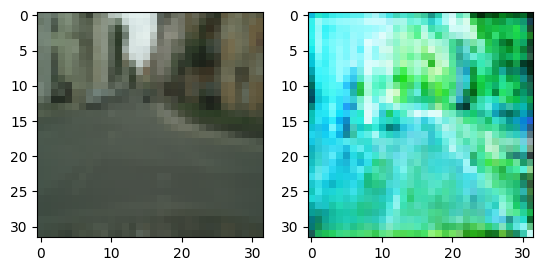

In [ ]:
import matplotlib.pyplot as plt

data = next(iter(dataloaders[step-1]))
noise = torch.randn(cur_batch_size, z_dim, 1, 1).to(device)

# # step = 4

fake = gen(noise, 1, step-1)
fig,ax = plt.subplots(1,2)


ax[0].imshow((data[0].detach().cpu().permute(1,2,0)+1)/2)
ax[1].imshow((fake[0].detach().cpu().permute(1,2,0)+1)/2)
(fake[0,0].mean(),fake[0,1].mean(),fake[0,2].mean())